# **Découverte des données**

In [186]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, classification_report

df = pd.read_csv('./train_data_accidents.csv')

Nous allons tout d'abord supprimer les valeurs ne nous permettant pas de prédire quoi que ce soit, c'est-à-dire les personnes en fuite.

In [187]:
df.drop(df.index[df['grav'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['sexe'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['place'] == -1], axis = 0, inplace = True)

Dans un premier temps, nous constatons que certaines valeurs de colonnes sont inutilisées / très peu représentées, nous avons donc décidés de les regrouper.

<Axes: >

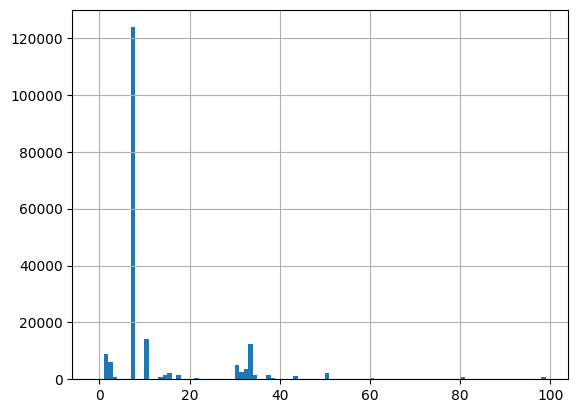

In [188]:
df['catv'].hist(bins = 100)

In [189]:
groupes_catv = {
    1: [1, 50, 60, 80], #vélos, hoverboard
    2: [2, 30, 4, 5, 6, 31, 32, 33, 34, 41, 42, 43, 35, 36], #les trucs de motos là
    4: [3, 7, 8, 9, 10, 11, 12], #Véhicules légers
    5: [13, 14, 15, 16, 17, 18, 19, 37, 38, 39, 40], #Gros poids lourd
    6: [20, 21, 0, 99] #Autres
}

for key, values in groupes_catv.items():
    df["catv"] = df["catv"].replace(values, key)


groupes_place = {
    2 : [2, 6],
    3 : [7, 8, 9],
    4 : [3, 4, 5]
}
for key, values in groupes_place.items():
    df["place"] = df["place"].replace(values, key)


groupes_undefined = {
    0 : [-1, 0]
}
for key, values in groupes_undefined.items():
    df["trajet"] = df["trajet"].replace(values, key)
    df["obs"] = df["obs"].replace(values, key)
    df['choc'] = df['choc'].replace(values, key)

groupes_obs = {
    3 : [3, 4, 5]
}
for key, values in groupes_obs.items():
    df["obs"] = df["obs"].replace(values, key)


groupes_obsm = {
    2 : [2, 4],
    5 : [5, 6]
}
for key, values in groupes_obsm.items():
  df["obsm"] = df["obsm"].replace(values, key)

groupe_choc = {
    1 : [1, 2, 3],
    4 : [4, 5, 6]
}
for key, values in groupe_choc.items():
  df["choc"] = df["choc"].replace(values, key)

groupes_manv = {
    11 : [11, 13, 15, 17],
    12 : [12, 14, 16, 18]
}
for key, values in groupes_manv.items():
  df["manv"].replace(values, key)

groupes_catr = {
    5 : [5, 6, 9]
}
for key, values in groupes_catr.items():
  df["catr"].replace(values, key)

groupes_surf = {
    3 : [3, 4, 5, 6, 7, 8, 9]
}
for key, values in groupes_surf.items():
  df["surf"].replace(values, key)

groupes_infra = {
    9 : [4, 6, 7, 8, 9]
}
for key, values in groupes_infra.items():
  df["infra"].replace(values, key)


# **Parsing**

Pour remplacer la colonne "hrmn", nous avons décidé d'en extraire seuelemtn l'heure de la journée (qui nous paraît plus pertinente), nous l'avons donc parsé comme ceci

In [190]:
df['heure'] = df['hrmn'].str.split(':').str[0]

De même avec l'âge des individus :

In [191]:
df = df.dropna(subset=['an_nais'])
df['age'] = 2021 - df['an_nais']

# **Regroupement**

In [192]:
df['is_protected'] = df[['secu1', 'secu2', 'secu3']].isin([1, 2, 3, 5, 6, 7]).any(axis=1).astype(int)
df.drop(columns=['jour', 'occutc', 'lat', 'long', 'hrmn', 'an_nais', 'secu1','secu2', 'secu3', 'vosp'], inplace=True)

# **Nettoyage des données (suppression des NaN, données non renseignées etc.)**

In [193]:
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == -1)], axis = 0, inplace = True)
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == 0)], axis = 0, inplace = True)
df.drop(df.index[(df['catv'] == -1)], axis = 0, inplace = True)

# **Normalisation**

In [194]:
colonnes_num = ['age', 'heure', 'mois']
scaler = StandardScaler()
df[colonnes_num] = scaler.fit_transform(df[colonnes_num])
#df.describe()

# **Séparation données / labels**

In [195]:
"""
labels = df['grav']
labels = labels - 1
df = df.drop(columns=["grav"])
"""

'\nlabels = df[\'grav\']\nlabels = labels - 1\ndf = df.drop(columns=["grav"])\n'

# **Création des dummies**

Afin d'empêcher les modèles de faire des corrélations entre certaines valeurs, nous avons utilisé le One-Hot-Encoding sur la majorité des features de notre jeu de données

In [196]:
"""
df = pd.get_dummies(df, columns=['place', 'catu', 'sexe', 'trajet', 'locp',
                                 'catv', 'obs', 'obsm', 'choc', 'manv','lum', 'agg', 'int', 'atm', 'col',
                                 'catr', 'circ', 'prof','plan', 'surf', 'infra', 'situ'])

print(len(df.columns))
"""

"\ndf = pd.get_dummies(df, columns=['place', 'catu', 'sexe', 'trajet', 'locp',\n                                 'catv', 'obs', 'obsm', 'choc', 'manv','lum', 'agg', 'int', 'atm', 'col',\n                                 'catr', 'circ', 'prof','plan', 'surf', 'infra', 'situ'])\n\nprint(len(df.columns))\n"

# **Variance**

In [197]:
variances = df.var(numeric_only=True)
print(variances.sort_values())

is_protected     0.134075
sexe             0.215853
agg              0.245475
catu             0.280904
prof             0.296196
plan             0.423464
surf             0.625986
circ             0.833705
locp             0.964315
mois             1.000005
heure            1.000005
age              1.000005
catv             1.118295
obsm             1.404293
situ             1.520724
grav             1.937514
lum              1.962691
catr             2.043961
col              2.558713
atm              2.757945
place            3.613004
int              3.831172
infra            4.053015
choc             5.832664
obs              7.269012
trajet           7.569325
manv            63.971354
dtype: float64


# **Création du modèle, entraînement et résultats**

In [198]:
#création des jeux d'entraînement et de test
#x_train, x_test, y_train, y_test = train_test_split(df, labels, test_size=0.25, train_size=0.75)

In [199]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

# 1. On sépare X et y avant toute transformation
X = df.drop('grav', axis=1)
y = df['grav']
y = y - 1

# 2. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Liste des colonnes à encoder
cat_cols = ['place', 'catu', 'sexe', 'trajet', 'locp', 'catv', 'obs',
            'obsm', 'choc', 'manv', 'lum', 'agg', 'int', 'atm', 'col',
            'catr', 'circ', 'prof', 'plan', 'surf', 'infra', 'situ']

# 4. Configuration du OneHotEncoder
# sparse_output=False permet d'obtenir un array utilisable directement
# handle_unknown='ignore' est l'avantage majeur par rapport à get_dummies
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# On fit uniquement sur le train
X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

# 5. Création des noms de colonnes pour retrouver la clarté de get_dummies
ohe_columns = ohe.get_feature_names_out(cat_cols)

# 6. Recomposition des DataFrames
X_train_final = pd.concat([
    X_train.drop(columns=cat_cols).reset_index(drop=True),
    pd.DataFrame(X_train_ohe, columns=ohe_columns)
], axis=1)

X_test_final = pd.concat([
    X_test.drop(columns=cat_cols).reset_index(drop=True),
    pd.DataFrame(X_test_ohe, columns=ohe_columns)
], axis=1)

# Maintenant tu peux appliquer ton StandardScaler sur X_train_final
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train_final)
x_test = scaler.transform(X_test_final)

print(f"Nombre de colonnes initial : {X.shape[1]}")
print(f"Nombre de colonnes générées par l'OHE : {len(ohe_columns)}")
print(f"Nombre de colonnes final : {X_train_final.shape[1]}")

Nombre de colonnes initial : 26
Nombre de colonnes générées par l'OHE : 174
Nombre de colonnes final : 178


In [200]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

max_iters = [50, 100, 200]
c_values = [0.01, 1, 10]
solvers = []

results = []

print("Lancement du test comparatif...")


for c in c_values:
  acc_list = []
  loss_list = []

  for m_iter in max_iters:
    model = LogisticRegression(
        max_iter=m_iter,
        C=c,
        solver='newton-cg',
        class_weight='balanced',
        random_state=42
    )

    model.fit(x_train_scaled, y_train)

    acc = model.score(x_test_scaled, y_test)
    probs = model.predict_proba(x_test_scaled)
    loss = log_loss(y_test, probs)

    acc_list.append(acc)
    loss_list.append(loss)

    print(f"C={c} | Iterations = {m_iter} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}")

  results.append({
      'label': f"(C={c})",
      'acc': acc_list,
      'loss': loss_list
  })

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(max_iters, res['acc'], marker='o', label=res['label'])
    ax2.plot(max_iters, res['loss'], marker='s', label=res['label'])

ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Nombre d'itérations")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True)

ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Lancement du test comparatif...


KeyboardInterrupt: 

In [ ]:
depths = [50, 100]
min_samples = [50, 100, 1000]

results = []

for ms in min_samples:
  acc_list = []
  loss_list = []

  for d in depths:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=ms,
        class_weight='balanced',
        random_state=42
    )
    model.fit(x_train, y_train)

    y_prob = model.predict_proba(x_test)
    y_pred = model.predict(x_test)

    loss = log_loss(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)

    acc_list.append(accuracy)
    loss_list.append(loss)
    print(f"Profondeur: {d} | Samples: {ms} | Score: {accuracy:.2%} | Loss: {loss}")

  results.append({
      'label': f"min_samples={ms}",
      'acc': acc_list,
      'loss': loss_list
  })

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(depths, res['acc'], marker='o', label=res['label'])
    ax2.plot(depths, res['loss'], marker='s', label=res['label'])

ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Profondeur")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True)

ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

On voit que les valeurs commencent à stagner autour d'une profondeur de 50 \
On constate qu'augmenter le nombre de min_samples ne fait pas tout, car la loss est très faible, mais l'accuracy aussi

In [201]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

nb_arbres = [50, 100, 200]
profondeurs = [20, 100]
results = []

for d in profondeurs:
  acc_par_step = []
  loss_par_step = []

  for n in nb_arbres:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=d,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(x_train, y_train)

    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)

    loss = log_loss(y_test, probs)
    accuracy = accuracy_score(y_test, preds)

    label_d = d if d is not None else "Max"
    print(f"Profondeur: {label_d} | Arbres: {n} | Score: {accuracy:.2%} | Loss: {loss:.4}")

    acc_par_step.append(accuracy)
    loss_par_step.append(loss)

  results.append({'depth': d, 'acc': acc_par_step, 'loss': loss_par_step})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for res in results:
    nom = f"Profondeur {res['depth']}"
    ax1.plot(nb_arbres, res['acc'], '-o', label=nom)
    ax2.plot(nb_arbres, res['loss'], '-s', label=nom)

ax1.set_title("Précision (Accuracy)")
ax1.legend()
ax2.set_title("Erreur (Log Loss)")
ax2.legend()
plt.show()

Profondeur: 20 | Arbres: 50 | Score: 59.26% | Loss: 0.9366


KeyboardInterrupt: 

On voit ici que les loss et accuracy stagnent à partir d'une profondeur de 100.
On remarque aussi que le nombre d'arbres utilisés améliore légèrement le résultat de nos tests

In [204]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(500, 'relu'),
    tf.keras.layers.Dense(1000, 'relu'),
    tf.keras.layers.Dense(500, 'relu'),
    tf.keras.layers.Dense(100, 'relu'),
    tf.keras.layers.Dense(10, 'relu'),
    tf.keras.layers.Dense(4, 'softmax'),
])

model.compile(
    optimizer = 'adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()
history = model.fit(x_train, y_train, epochs = 8, validation_data = (x_test, y_test))
model.evaluate(x_test, y_test, verbose=2)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 500)            │        89,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1000)           │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,154 (4.36 MB)

 Trainable params: 1,142,154 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 96s 20ms/step - accuracy: 0.5127 - loss: 0.9862 - val_accuracy: 0.5506 - val_loss: 0.9342
Epoch 2/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 148s 21ms/step - accuracy: 0.5574 - loss: 0.9268 - val_accuracy: 0.5528 - val_loss: 0.9230
Epoch 3/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 92s 20ms/step - accuracy: 0.5682 - loss: 0.9034 - val_accuracy: 0.5684 - val_loss: 0.9118
Epoch 4/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 95s 20ms/step - accuracy: 0.5809 - loss: 0.8848 - val_accuracy: 0.5712 - val_loss: 0.9100
Epoch 5/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 95s 20ms/step - accuracy: 0.5939 - loss: 0.8625 - val_accuracy: 0.5742 - val_loss: 0.9097
Epoch 6/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 140s 20ms/step - accuracy: 0.6058 - loss: 0.8386 - val_accuracy: 0.5782 - val_loss: 0.9136
Epoch 7/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 94s 20ms/step - accuracy: 0.6200 - loss: 0.8071 - val_accuracy: 0.5756 - val_loss: 0.9159
Epoch 8/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 95s 20ms/step - accuracy: 0.6365 - loss:

[0.917418897151947, 0.5797349810600281]

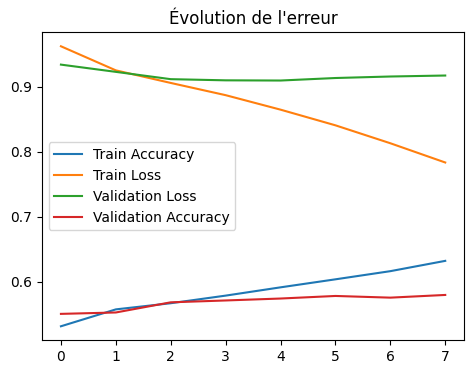

In [206]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Évolution de la précision')
plt.legend()

plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de l\'erreur')
plt.legend()
plt.show()

### Avec regroupements (160 colonnes) :
[Loss, Accuracy]

LogisticRegression (lbfgs/newton-cg c=0.01) : [1.17, 0.44]\
DecisionTreeClassifier (Profondeur 50-100, min_samples 50-1000) :  [2.73-1.20,0.44-0.47]\
RandomForestClassifier (Profondeur 20-100, Nombre d'arbres 50-200) : [0.95-0.84, 0.46-0.63] \
Réseau de neurones (8 epochs) : [0.91, 0.57]

Avec nos colonnes et optimisation actuelles, tous les modèles finissent par faire de l'overfitting (haute accuracy / faible loss en entraînement, accuracy moyenne / loss moyenne en test)